### Single Source Fit (Cas A)

In [1]:
from cosipy import BinnedData, UnBinnedData#, COSILike
# from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.response.PointSourceResponse import PointSourceResponse

# from COSILikeNew import COSILike
from cosipy.interfaces import ThreeMLPluginInterface

from scoords import SpacecraftFrame

import astropy.units as u
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler
from scipy.optimize import curve_fit, minimize
import pandas as pd
from lmfit import Model
from lmfit.models import GaussianModel

from threeML import Line, Gaussian, Cauchy, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter
from histpy import Histogram, Axes, Axis, HealpixAxis
from tqdm import tqdm

from pathlib import Path

import os

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['b', 'r', 'limegreen']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

14:26:35 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=110802;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=291929;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=97373;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=639953;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=13894;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=540864;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=255494;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=342777;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

14:26:37 WARNING   No fermitools installed                                              ]8;id=141639;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=363487;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=629868;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=886325;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=898755;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=152024;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=720520;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=996794;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
# Data directory
DATA_DIR = Path('/Users/penguin/Documents/Research/COSI/COSIpy/docs/DC4/')

In [3]:
psr_filename = '/Users/penguin/Documents/Research/COSI/COSIpy/docs/DC4/data/responses/extended_source_response_Ti44_merged.h5'
psr = Histogram.open(psr_filename)


# Create binned data object for sources
data_obj = BinnedData("inputs.yaml")
data_loader_obj = BinnedData("inputs.yaml")

# Create binned data object for background
bg_obj = BinnedData("inputs.yaml")

data_obj.load_binned_data_from_hdf5('44Ti_binned_data.hdf5')
bg_obj.load_binned_data_from_hdf5('../data/backgrounds/binned/gal_DC4_bkg_Ti44_binned_smoothed_fwhm_10.0deg.hdf5')


# Alternately, use source injector to create template models
# Use the same pre-computed response file with a fairly representative
# flux. For a narrow 1154-1160 keV energy bin, the exact spectral 
# shape wouldn't matter (i.e., wouldn't impart any biases in the Phi,
# PsiChi axes)

In [4]:
from cosipy.spacecraftfile import SpacecraftHistory

sc_orientation = SpacecraftHistory.open(DATA_DIR.parent / "DC3/data/orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori")

In [5]:
from cosipy.data_io import EmCDSBinnedData
from cosipy.background_estimation import FreeNormBinnedBackground

tiny = 1e-12

bg = bg_obj.binned_data.project('Em', 'Phi', 'PsiChi')
bkg = FreeNormBinnedBackground(bg + tiny,
                               sc_history=sc_orientation,
                               copy = False)

data = EmCDSBinnedData(data_obj.binned_data.project('Em', 'Phi', 'PsiChi'))     # Need all 3 months data to use with pre-computed response and background


WARNING RuntimeWarning: divide by zero encountered in divide



In [6]:
from cosipy.response import PointSourceResponse, ExtendedSourceResponse, BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLPointSourceResponse
from cosipy.statistics import PoissonLikelihood

esr = ExtendedSourceResponse.open(psr_filename)

class FixedPSRWrapper:
    def __init__(self, psr):
        self._psr = psr
        self._source = None

    @property
    def axes(self):
        # BinnedThreeMLModelFolding uses this to validate axes
        return self._psr.measurement_axes  # ('Em','Phi','PsiChi') axes

    def copy(self):
        # safe copy for multiple sources
        return FixedPSRWrapper(self._psr)

    def set_source(self, source):
        # optional: you can enforce it’s a PointSource, store it
        self._source = source

    def expectation(self, copy=True):
        if self._source is None:
            raise RuntimeError("Call set_source() first.")
        h = self._psr.get_expectation(self._source.spectrum.main.shape)
        return h.copy() if copy else h

In [7]:
# define the target coordinates (Cas A)
target_coord = SkyCoord.from_name('Cas A').galactic

In [8]:
import mhealpy as hp
nside = 16
idx = hp.ang2pix(nside, target_coord.l.value, target_coord.b.value, lonlat=True)
psr = PointSourceResponse(esr.axes[1:], contents=esr[idx], unit=esr.unit)

In [9]:
# Initialize the 3ML Point Source response

# Pass the 3ML Point Source response to interface implementation that will peform the 
# folding with the spectrum
response = BinnedThreeMLModelFolding(data = data, point_source_response = FixedPSRWrapper(psr))

# Likelihood to use
like_fun = PoissonLikelihood(data, response, bkg)

In [10]:
# Init 3ML plugin
cosi = ThreeMLPluginInterface('cosi',
                              like_fun,
                              response,
                              bkg)

# Init background parameters, consider as "nuisance parameters"
cosi.bkg_parameter['bkg_norm'] = Parameter('bkg_norm',  # background parameter
                                    1,  # initial value of parameter
                                    min_value=0.8,  # minimum value of parameter
                                    max_value=1.2,  # maximum value of parameter
                                    delta=0.05,  # initial step used by fitting engine
                                    unit = u.Hz,
                                    free = True
                                    )

In [11]:
F = 1e-4 * 1 / u.cm / u.cm / u.s
mu = 1157 * u.keV
sigma = 3.85e-1 * u.keV         # Contain the entire spread within the energy bin

spectrum = Gaussian()
spectrum.F.value = F.value
spectrum.F.unit = F.unit
spectrum.F.max_value = F * 100
spectrum.F.min_value = F / 100
spectrum.mu.value = mu.value 
spectrum.mu.unit = mu.unit
spectrum.mu.free = False
spectrum.sigma.value = sigma.value
spectrum.sigma.unit = sigma.unit
spectrum.sigma.free = False
source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = target_coord.l.value,     # Longitude (deg)
                     b = target_coord.b.value,     # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# Optional: free the position parameters
#source.position.l.free = True
#source.position.b.free = True

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

In [12]:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

_ = like.fit()

14:26:42 INFO      set the minimizer to minuit                                             ]8;id=130995;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=627305;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

14:26:43 WARNING   76.42 percent of samples have been thrown away because they failed the  ]8;id=993470;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=353488;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/analysis_results.py#1740\1740]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

14:26:43 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=147830;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=306400;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Gaussian.F,(1.000000 +/- 0.000005) x 10^-6,1 / (s cm2)
bkg_norm,(8.00000000000 +/- 0.00000000007) x 10^-1,Hz


...

1.00,-0.00
-0.00,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,4722369.7513902495
total,4722369.7513902495


Values of statistical measures:

,statistical measures
AIC,9444743.502845604
BIC,9444763.751637813


In [13]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Gaussian.F,(1.000000 +/- 0.000005) x 10^-6,1 / (s cm2)
bkg_norm,(8.00000000000 +/- 0.00000000007) x 10^-1,Hz


Correlation matrix:

1.00,-0.00
-0.00,1.00


Values of -log(likelihood) at the minimum:

...

None


         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=844631;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=299084;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=507468;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=471465;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=719864;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=199149;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

  * source (point source):
    * position:
      * l:
        * value: 111.73761886012026
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: -2.1345070675804516
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Gaussian:
          * F:
            * value: 1.0000000004928897e-06
            * desc: Integral between -inf and +inf. Fix this to 1 to obtain a Normal distribution
            * min_value: 1.0e-06
            * max_value: 0.01
            * unit: s-1 cm-2
            * is_normalization: false
          * mu:
            * value: 1157.0
            * desc: Central value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * sigma:
 

In [14]:
F_inj = 4.76e-6 * 1 / u.cm / u.cm / u.s

spectrum_inj = Gaussian()
spectrum_inj.F.value = F_inj.value
spectrum_inj.F.unit = F_inj.unit
spectrum_inj.mu.value = mu.value 
spectrum_inj.mu.unit = mu.unit
spectrum_inj.sigma.value = sigma.value
spectrum_inj.sigma.unit = sigma.unit

In [15]:
energy = np.linspace(1150*u.keV,1164*u.keV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)
    
binned_energy_edges = bg.axes['Em'].edges.value
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = response.expectation()

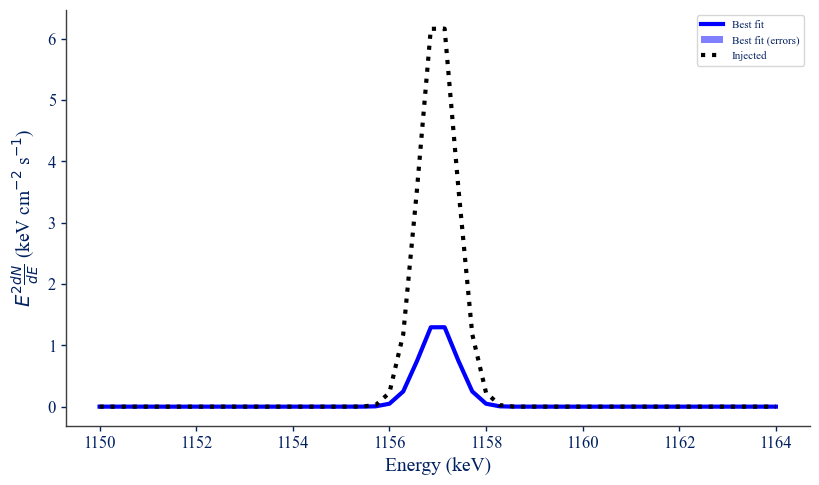

In [16]:
fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

# ax.set_xscale("log")
# ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

# ax.set_ylim(.1,100)
# ax.set_xlim(1155, 1159)

_ = ax.legend()

In [17]:
raise

RuntimeError: No active exception to reraise

### Stacked Analysis

In [ ]:
# Stacked Analysis (multi-target; morphology / ESR path)
#
# Logical flow:
# 1) Stack many binned `(Em, Phi, PsiChi)` histograms into one dataset (`data_stack`).
# 2) Build the same likelihood stack as elsewhere: PoissonLikelihood + ThreeML plugin.
# 3) Fold ExtendedSources through the merged `ExtendedSourceResponse` (`esr`) via
#    `BinnedThreeMLExtendedSourceResponse`.

# --- Targets to fit (5 total) ---
# Use `.galactic` so l/b are consistent with HEALPix Galactic indexing implied by `esr`.

target_coords = [
    SkyCoord.from_name('SN1987A').galactic,
    SkyCoord.from_name('Tycho').galactic,
    SkyCoord(l=4.5, b=6.8, unit='deg', frame=Galactic()),
    SkyCoord(l=266.3, b=-1.2, unit='deg', frame=Galactic()),
    SkyCoord(l=1.9, b=0.3, unit='deg', frame=Galactic()),
]

if len(target_coords) != 5:
    raise ValueError(f"Expected 5 target_coords, got {len(target_coords)}")

In [29]:
# --- Response + likelihood for stacked dataset (ExtendedSourceResponse) ---
#
# Requires `ExtendedSource` models below (narrow Gaussian_on_sphere morphology).

from cosipy.response import BinnedThreeMLExtendedSourceResponse


esr_stack = BinnedThreeMLExtendedSourceResponse(data=data, precomputed_psr=esr)

response_stack = BinnedThreeMLModelFolding(
    data=data,
    extended_source_response=esr_stack,
)

like_fun_stack = PoissonLikelihood(data, response_stack, bkg)

cosi_stack = ThreeMLPluginInterface(
    "cosi_stack",
    like_fun_stack,
    response_stack,
    bkg,
)

cosi_stack.bkg_parameter["bkg_norm"] = Parameter(
    "bkg_norm",
    1,
    min_value=0,
    max_value=100,
    delta=0.05,
    unit=u.Hz,
)

In [30]:
# --- Define sources (narrow extended morphology approximating a point source) ---

from copy import deepcopy

from astromodels import ExtendedSource, Gaussian_on_sphere

F0 = 1e-4 * 1 / u.cm / u.cm / u.s
mu0 = 1157 * u.keV
sigma0 = 3.85e-1 * u.keV  # contain the entire spread within the energy bin

base_spec = Gaussian()
base_spec.F.value = F0.value
base_spec.F.unit = F0.unit
base_spec.F.max_value = (F0 * 100).value
base_spec.F.min_value = (F0 / 100).value
base_spec.mu.value = mu0.value
base_spec.mu.unit = mu0.unit
base_spec.mu.free = False
base_spec.sigma.value = sigma0.value
base_spec.sigma.unit = sigma0.unit
base_spec.sigma.free = False

# HEALPix-limited surrogate for a delta on the sphere: tweak if you need it tighter.
MORPH_SIGMA_DEG = 0.25

extended_sources = []

for i, c in enumerate(target_coords):
    spec_i = deepcopy(base_spec)

    morph = Gaussian_on_sphere(lon0=c.l.deg, lat0=c.b.deg, sigma=MORPH_SIGMA_DEG)
    morph.lon0.free = False
    morph.lat0.free = False
    morph.sigma.free = False

    src = ExtendedSource(
        f"src_{i}",
        spectral_shape=spec_i,
        spatial_shape=morph,
    )
    extended_sources.append(src)


In [31]:
# --- Build the model and link fluxes across all 5 sources ---

model_stack = Model(*extended_sources)

# Fit one common flux parameter shared by all targets (like a stacked/average flux)
for i in range(1, len(extended_sources)):
    model_stack.link(
        getattr(model_stack, extended_sources[0].name).spectrum.main.Gaussian.F,
        getattr(model_stack, extended_sources[i].name).spectrum.main.Gaussian.F,
    )

# --- Fit ---
jl_stack = JointLikelihood(model_stack, DataList(cosi_stack))
fit_results_stack = jl_stack.fit()

fit_results_stack

16:20:27 INFO      set the minimizer to minuit                                             ]8;id=359553;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=613609;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

16:20:40 WARNING   93.66 percent of samples have been thrown away because they failed the  ]8;id=402107;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=959823;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/analysis_results.py#1740\1740]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

16:20:40 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=149166;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=855612;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=915577;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=584016;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=206603;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=385919;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_stack,121609.38756471244
total,121609.38756471244


Values of statistical measures:

,statistical measures
AIC,243228.7754549563
BIC,243279.3972727073


(                                   value  negative_error  positive_error  \
 src_1.spectrum.main.Gaussian.F  0.000171    2.534668e-04    2.305946e-03   
 src_2.spectrum.main.Gaussian.F  0.000001    2.130139e-07    1.459210e-06   
 src_3.spectrum.main.Gaussian.F  0.000001    4.985944e-07    4.467451e-06   
 src_4.spectrum.main.Gaussian.F  0.000001    6.247199e-10    3.876193e-09   
 bkg_norm                        0.021916   -5.159586e-05    5.398224e-05   
 
                                        error         unit  
 src_1.spectrum.main.Gaussian.F  1.279707e-03  1 / (s cm2)  
 src_2.spectrum.main.Gaussian.F  8.361120e-07  1 / (s cm2)  
 src_3.spectrum.main.Gaussian.F  2.483023e-06  1 / (s cm2)  
 src_4.spectrum.main.Gaussian.F  2.250457e-09  1 / (s cm2)  
 bkg_norm                        5.278905e-05           Hz  ,
               -log(likelihood)
 cosi_stack  121609.38756471244
 total       121609.38756471244)

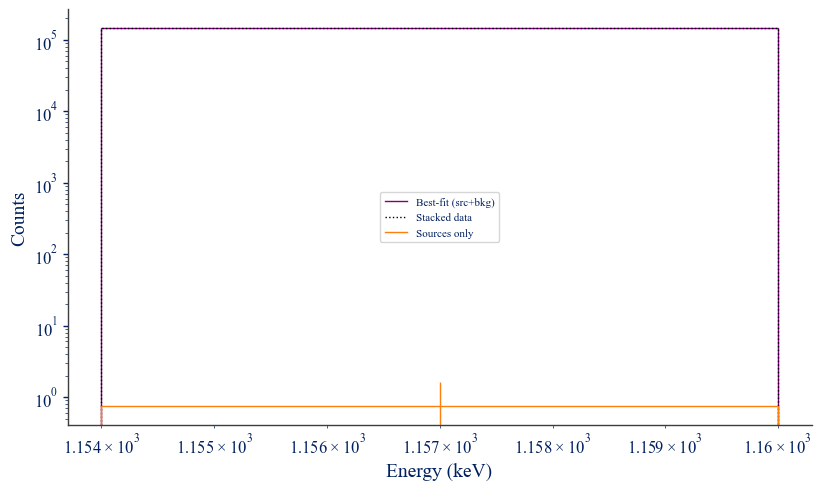

In [34]:
# --- Plot folded model vs stacked data (projection on Em) ---

total_expectation = response_stack.expectation(data)

binned_energy_edges = data.axes['Em'].edges.value
binned_energy = data.axes['Em'].centers.value

sources_expectation = response_stack.expectation()
bkg_expectation = bkg.expectation(copy=True)

total_with_bkg = sources_expectation + bkg_expectation

fig, ax = plt.subplots()

ax.stairs(total_with_bkg.project('Em').todense().contents, binned_energy_edges, color='purple', label="Best-fit (src+bkg)")
ax.errorbar(binned_energy, total_with_bkg.project('Em').todense().contents, yerr=np.sqrt(total_with_bkg.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)

ax.stairs(data.data.project('Em').todense().contents, binned_energy_edges, color='black', ls=":", label="Stacked data")
ax.errorbar(binned_energy, data.data.project('Em').todense().contents, yerr=np.sqrt(data.data.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.stairs(total_expectation.project('Em').todense().contents, binned_energy_edges, color='tab:orange', label="Sources only")
ax.errorbar(binned_energy, total_expectation.project('Em').todense().contents, yerr=np.sqrt(total_expectation.project('Em').todense().contents), color='tab:orange', linewidth=0, elinewidth=1)

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.set_yscale('log')
ax.set_xscale('log')
ax.legend()
plt.show()


Best fit values:

,result,unit
parameter,,
src_1.spectrum.main.Gaussian.F,(0.2 +/- 1.8) x 10^-3,1 / (s cm2)
src_2.spectrum.main.Gaussian.F,(1.0 +/- 1.1) x 10^-6,1 / (s cm2)
src_3.spectrum.main.Gaussian.F,(1.0 +/- 2.8) x 10^-6,1 / (s cm2)
src_4.spectrum.main.Gaussian.F,(1.0000 +/- 0.0028) x 10^-6,1 / (s cm2)
bkg_norm,(2.192 +/- 0.006) x 10^-2,Hz


Correlation matrix:

1.00,-0.00,-0.00,0.00,-0.00
-0.00,1.00,-0.00,0.00,-0.00
-0.00,-0.00,1.00,0.00,-0.00
0.00,0.00,0.00,1.00,0.00
-0.00,-0.00,-0.00,0.00,1.00


Values of -log(likelihood) at the minimum:

...

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=270752;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=982532;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=334113;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=553328;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=754099;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=328985;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=270001;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=601558;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter F (1.0) was above the new maximum 0.01.      ]8;id=514434;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=122385;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

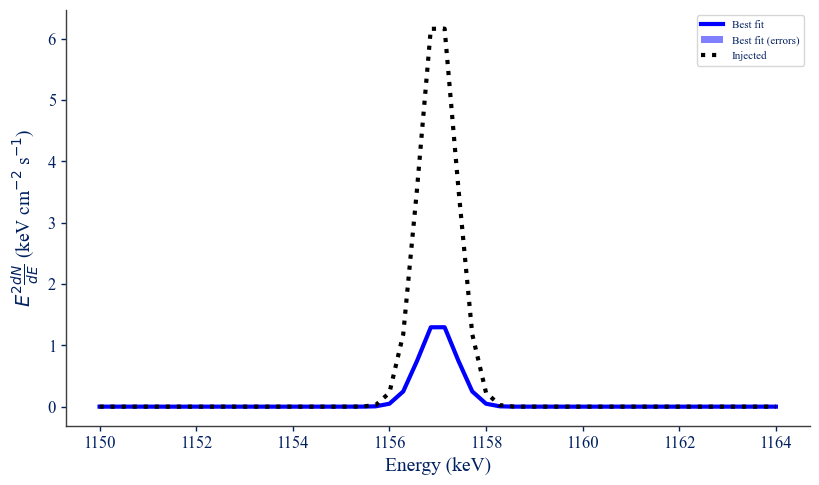

In [35]:
# --- Deconvolved spectrum plot (linked flux across the 5 sources) ---

ref_name = extended_sources[0].name

results_stack = jl_stack.results
print(results_stack.display())

parameters = {
    par.name: results_stack.get_variates(par.path)
    for par in results_stack.optimized_model[ref_name].parameters.values()
    if par.free
}

results_stack_err = results_stack.propagate(
    results_stack.optimized_model[ref_name].spectrum.main.shape.evaluate_at,
    **parameters,
)

energy = np.linspace(1150 * u.keV, 1164 * u.keV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj_plot = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_stack_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj_plot[i] = spectrum_inj.evaluate_at(e)

fig, ax = plt.subplots()

ax.plot(energy, energy * energy * flux_median, label="Best fit")
ax.fill_between(energy, energy * energy * flux_lo, energy * energy * flux_hi, alpha=.5, label="Best fit (errors)")
ax.plot(energy, energy * energy * flux_inj_plot, color='black', ls=":", label="Injected")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

_ = ax.legend()
plt.show()
